# Chunking Strategy Retrieval Evaluation

This notebook compares two chunking strategies on the same KDK document set, embedding model, vector database, and test questions.

- `baseline_recursive`: raw `RecursiveCharacterTextSplitter`
- `structured_filtered`: Markdown-aware splitting with short-heading cleanup and short-chunk filtering

The notebook focuses on retrieval quality rather than answer generation quality:

1. Chunk statistics and noise analysis
2. Qdrant ingestion with the same embedding model for both strategies
3. Retrieval evaluation on the 30 KDK test questions
4. Hit@1 / Hit@5 / Hit@20, first relevant rank, and MRR
5. Visual comparison and failure inspection


In [1]:
import json
import re
import time
from pathlib import Path

import matplotlib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import requests
import seaborn as sns
from tqdm.auto import tqdm

from langchain_ollama import OllamaEmbeddings
from langchain_text_splitters import MarkdownHeaderTextSplitter, RecursiveCharacterTextSplitter
from qdrant_client import QdrantClient
from qdrant_client.models import Distance, PointStruct, VectorParams

sns.set_theme(style="whitegrid", palette="muted")
matplotlib.rcParams["figure.dpi"] = 120
print("Imports OK")


Imports OK


In [2]:
ROOT_DIR = Path("..").resolve()
DOCS_DIR = ROOT_DIR / "data" / "kdk" / "docs"
OUTPUT_DIR = ROOT_DIR / "outputs"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

QDRANT_URL = "http://localhost:6333"
OLLAMA_URL = "http://localhost:11434"
EMBEDDING_MODEL = "nomic-embed-text"
JUDGE_MODEL = "qwen2.5:7b"

BASELINE_COLLECTION = "nb04_baseline_recursive"
FILTERED_COLLECTION = "nb04_structured_filtered"

RESET_ARTIFACTS = True
TOP_K_EVAL = 20
EMBED_BATCH_SIZE = 32

MIN_SECTION_CHARS = 120
MIN_FINAL_CHARS = 80
MAX_CHUNK_CHARS = 1000
CHUNK_OVERLAP = 150

RETRIEVAL_EVAL_PATH = OUTPUT_DIR / "nb04_retrieval_eval.json"
CHUNK_STATS_PATH = OUTPUT_DIR / "nb04_chunk_stats.csv"

print(f"Docs dir: {DOCS_DIR} (exists={DOCS_DIR.exists()})")
print(f"Qdrant: {QDRANT_URL}")
print(f"Embedding model: {EMBEDDING_MODEL}")
print(f"Judge model: {JUDGE_MODEL}")
print(f"Reset artifacts: {RESET_ARTIFACTS}")


Docs dir: D:\kalisio\code_rag\data\kdk\docs (exists=True)
Qdrant: http://localhost:6333
Embedding model: nomic-embed-text
Judge model: qwen2.5:7b
Reset artifacts: True


In [3]:
def parse_test_questions(path: Path) -> list[dict]:
    text = path.read_text(encoding="utf-8")
    questions = []
    difficulty = "Unknown"
    for line in text.splitlines():
        line = line.strip()
        if line.startswith("## "):
            difficulty = line[3:].strip()
        match = re.match(r"^(\d+)\.\s+(.+)$", line)
        if match:
            questions.append({
                "question_id": int(match.group(1)),
                "difficulty": difficulty,
                "question": match.group(2),
            })
    return questions


def strip_frontmatter(text: str) -> str:
    lines = text.splitlines()
    if len(lines) >= 3 and lines[0].strip() == "---":
        for i in range(1, len(lines)):
            if lines[i].strip() == "---":
                return "\n".join(lines[i + 1:]).strip()
    return text.strip()


def extract_doc_title(text: str, fallback: str) -> str:
    for line in text.splitlines():
        if line.startswith("# ") and not line.startswith("## "):
            return line[2:].strip()
    return fallback


def is_heading_only(text: str) -> bool:
    stripped = text.strip()
    if not stripped:
        return True
    lines = [line.strip() for line in stripped.splitlines() if line.strip()]
    return len(lines) == 1 and lines[0].startswith("#")


questions = parse_test_questions(ROOT_DIR / "test_questions_en.md")
print(f"Loaded {len(questions)} test questions")
questions[:3]


Loaded 30 test questions


[{'question_id': 1,
  'difficulty': 'Easy',
  'question': 'What does KDK stand for?'},
 {'question_id': 2,
  'difficulty': 'Easy',
  'question': 'What is the main goal of the Kalisio Development Kit?'},
 {'question_id': 3,
  'difficulty': 'Easy',
  'question': 'What kind of applications is KDK designed to help build?'}]

In [4]:
baseline_splitter = RecursiveCharacterTextSplitter(
    chunk_size=MAX_CHUNK_CHARS,
    chunk_overlap=200,
    separators=["\n## ", "\n### ", "\n\n", "\n", " "],
)

structured_splitter = MarkdownHeaderTextSplitter(
    headers_to_split_on=[("#", "h1"), ("##", "h2"), ("###", "h3")],
    strip_headers=False,
)

final_splitter = RecursiveCharacterTextSplitter(
    chunk_size=MAX_CHUNK_CHARS,
    chunk_overlap=CHUNK_OVERLAP,
    separators=["\n\n", "\n", " "],
)


def metadata_from_header(doc_title: str, rel_path: str, metadata: dict) -> dict:
    section_parts = [metadata.get(key, "").strip() for key in ("h1", "h2", "h3") if metadata.get(key)]
    return {
        "source": rel_path,
        "doc_title": doc_title,
        "section_title": " / ".join(section_parts) if section_parts else doc_title,
    }


def chunk_baseline_recursive(docs_dir: Path) -> list[dict]:
    chunks = []
    for filepath in sorted(docs_dir.rglob("*.md")):
        raw_text = filepath.read_text(encoding="utf-8")
        text = strip_frontmatter(raw_text)
        rel_path = str(filepath.relative_to(docs_dir))
        doc_title = extract_doc_title(text, filepath.stem)
        docs = baseline_splitter.create_documents(
            [text],
            metadatas=[{"source": rel_path, "doc_title": doc_title, "section_title": doc_title}],
        )
        for doc in docs:
            chunks.append({"text": doc.page_content.strip(), "metadata": dict(doc.metadata)})
    return chunks


def merge_short_sections(sections: list[dict], min_chars: int) -> list[dict]:
    merged = []
    i = 0
    while i < len(sections):
        current = sections[i]
        text = current["text"].strip()
        metadata = dict(current["metadata"])
        while (is_heading_only(text) or len(text) < min_chars) and i + 1 < len(sections):
            i += 1
            nxt = sections[i]
            text = f"{text}\n\n{nxt['text'].strip()}".strip()
            metadata = dict(nxt["metadata"])
        merged.append({"text": text, "metadata": metadata})
        i += 1
    return merged


def chunk_structured_filtered(docs_dir: Path) -> list[dict]:
    chunks = []
    for filepath in sorted(docs_dir.rglob("*.md")):
        raw_text = filepath.read_text(encoding="utf-8")
        text = strip_frontmatter(raw_text)
        rel_path = str(filepath.relative_to(docs_dir))
        doc_title = extract_doc_title(text, filepath.stem)
        header_docs = structured_splitter.split_text(text)
        sections = []
        for doc in header_docs:
            section_text = doc.page_content.strip()
            if not section_text:
                continue
            sections.append({
                "text": section_text,
                "metadata": metadata_from_header(doc_title, rel_path, doc.metadata),
            })
        merged_sections = merge_short_sections(sections, MIN_SECTION_CHARS)
        for section in merged_sections:
            split_docs = final_splitter.create_documents([section["text"]], metadatas=[section["metadata"]])
            for doc in split_docs:
                text_part = doc.page_content.strip()
                if not text_part:
                    continue
                if is_heading_only(text_part):
                    continue
                if len(text_part) < MIN_FINAL_CHARS:
                    continue
                chunks.append({"text": text_part, "metadata": dict(doc.metadata)})
    return chunks


baseline_chunks = chunk_baseline_recursive(DOCS_DIR)
filtered_chunks = chunk_structured_filtered(DOCS_DIR)
print(f"Baseline chunks: {len(baseline_chunks)}")
print(f"Structured/filtered chunks: {len(filtered_chunks)}")


Baseline chunks: 873
Structured/filtered chunks: 1087


In [5]:
def chunk_stats_df(chunks: list[dict], strategy: str) -> pd.DataFrame:
    rows = []
    for chunk in chunks:
        text = chunk["text"]
        rows.append({
            "strategy": strategy,
            "source": chunk["metadata"].get("source", ""),
            "section_title": chunk["metadata"].get("section_title", ""),
            "length": len(text),
            "line_count": len([line for line in text.splitlines() if line.strip()]),
            "heading_only": is_heading_only(text),
            "short_le_80": len(text) <= 80,
            "text": text,
        })
    return pd.DataFrame(rows)


chunk_df = pd.concat([
    chunk_stats_df(baseline_chunks, "baseline_recursive"),
    chunk_stats_df(filtered_chunks, "structured_filtered"),
], ignore_index=True)

summary = chunk_df.groupby("strategy").agg(
    total_chunks=("length", "size"),
    mean_length=("length", "mean"),
    median_length=("length", "median"),
    max_length=("length", "max"),
    min_length=("length", "min"),
    short_le_80=("short_le_80", "sum"),
    heading_only=("heading_only", "sum"),
).round(2)
summary["short_pct"] = (summary["short_le_80"] / summary["total_chunks"] * 100).round(2)
summary["heading_only_pct"] = (summary["heading_only"] / summary["total_chunks"] * 100).round(2)
summary


,total_chunks,mean_length,median_length,max_length,min_length,short_le_80,heading_only,short_pct,heading_only_pct
strategy,,,,,,,,,
baseline_recursive,873,603.96,660.0,999,3,54,39,6.19,4.47
structured_filtered,1087,475.76,367.0,999,82,0,0,0.00,0.00


Saved chunk stats to D:\kalisio\code_rag\outputs\nb04_chunk_stats.csv


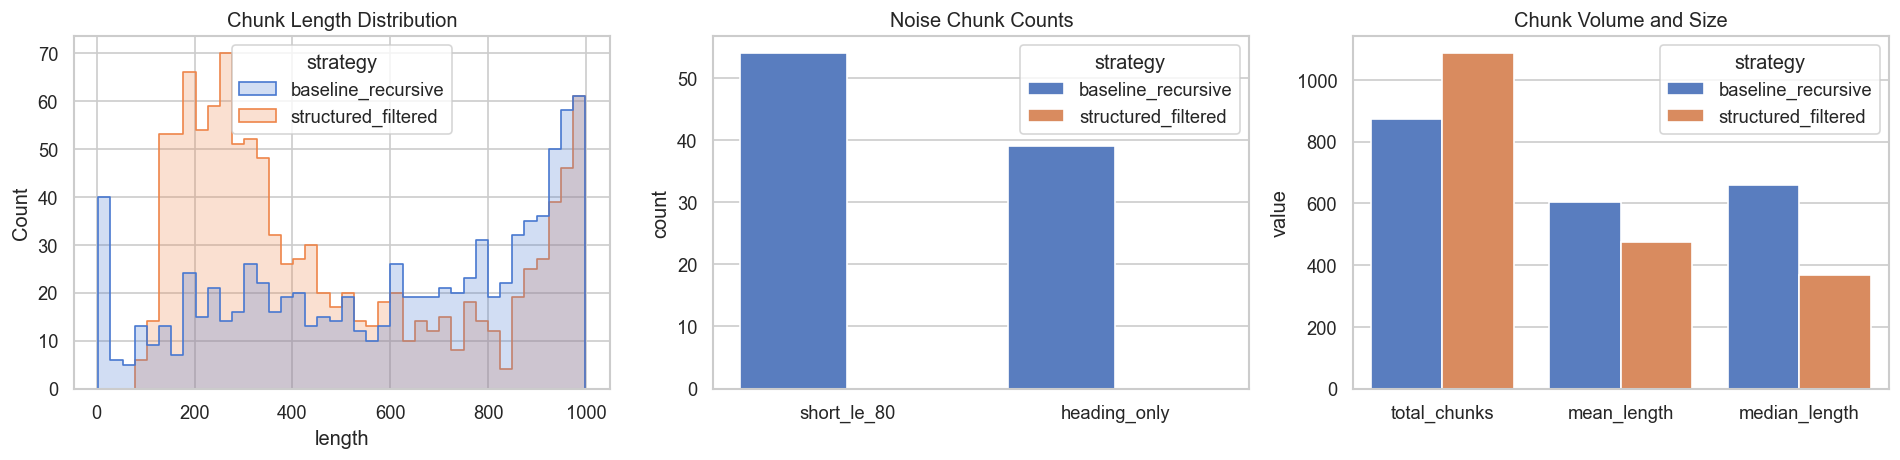

In [6]:
CHUNK_STATS_PATH.write_text(chunk_df.drop(columns=["text"]).to_csv(index=False), encoding="utf-8")
print(f"Saved chunk stats to {CHUNK_STATS_PATH}")

fig, axes = plt.subplots(1, 3, figsize=(16, 4))

sns.histplot(data=chunk_df, x="length", hue="strategy", bins=40, ax=axes[0], element="step", stat="count", common_norm=False)
axes[0].set_title("Chunk Length Distribution")

noise_df = summary.reset_index()[["strategy", "short_le_80", "heading_only"]].melt(id_vars="strategy", var_name="metric", value_name="count")
sns.barplot(data=noise_df, x="metric", y="count", hue="strategy", ax=axes[1])
axes[1].set_title("Noise Chunk Counts")
axes[1].set_xlabel("")

size_df = summary.reset_index()[["strategy", "total_chunks", "mean_length", "median_length"]].melt(id_vars="strategy", var_name="metric", value_name="value")
sns.barplot(data=size_df, x="metric", y="value", hue="strategy", ax=axes[2])
axes[2].set_title("Chunk Volume and Size")
axes[2].set_xlabel("")

plt.tight_layout()
plt.show()


In [7]:
embeddings = OllamaEmbeddings(model=EMBEDDING_MODEL, base_url=OLLAMA_URL)
qdrant = QdrantClient(url=QDRANT_URL)


def reset_collections() -> None:
    for collection in [BASELINE_COLLECTION, FILTERED_COLLECTION]:
        if qdrant.collection_exists(collection):
            qdrant.delete_collection(collection)
            print(f"Deleted collection: {collection}")
    if RETRIEVAL_EVAL_PATH.exists():
        RETRIEVAL_EVAL_PATH.unlink()
        print(f"Removed cache: {RETRIEVAL_EVAL_PATH.name}")


def embed_in_batches(texts: list[str], batch_size: int = EMBED_BATCH_SIZE) -> np.ndarray:
    vectors = []
    for start in tqdm(range(0, len(texts), batch_size), desc="Embedding"):
        batch = texts[start:start + batch_size]
        vectors.extend(embeddings.embed_documents(batch))
    return np.array(vectors)


def ingest_chunks(collection_name: str, chunks: list[dict]) -> np.ndarray:
    texts = [chunk["text"] for chunk in chunks]
    vectors = embed_in_batches(texts)

    if qdrant.collection_exists(collection_name):
        qdrant.delete_collection(collection_name)
    qdrant.create_collection(
        collection_name=collection_name,
        vectors_config=VectorParams(size=vectors.shape[1], distance=Distance.COSINE),
    )

    points = [
        PointStruct(
            id=i,
            vector=vectors[i].tolist(),
            payload={"text": chunks[i]["text"], **chunks[i]["metadata"]},
        )
        for i in range(len(chunks))
    ]
    qdrant.upsert(collection_name=collection_name, points=points)
    info = qdrant.get_collection(collection_name)
    print(f"{collection_name}: {info.points_count} points")
    return vectors


if RESET_ARTIFACTS:
    reset_collections()

baseline_vectors = ingest_chunks(BASELINE_COLLECTION, baseline_chunks)
filtered_vectors = ingest_chunks(FILTERED_COLLECTION, filtered_chunks)


Embedding:   0%|          | 0/28 [00:00<?, ?it/s]

nb04_baseline_recursive: 873 points


Embedding:   0%|          | 0/34 [00:00<?, ?it/s]

nb04_structured_filtered: 1087 points


In [8]:
RETRIEVAL_JUDGE_PROMPT = """You are evaluating retrieval quality for a RAG system.

Question:
{question}

Retrieved chunks:
{retrieved_chunks}

Determine the first chunk rank that contains enough information to answer the question directly and faithfully from the retrieved text alone.

Rules:
- A chunk is relevant only if it contains the answer, not just related terminology.
- If no chunk in the list is sufficient, return null for first_relevant_rank.
- Also return booleans for has_answer_top1, has_answer_top5, has_answer_top20.

Return only JSON with keys:
first_relevant_rank, has_answer_top1, has_answer_top5, has_answer_top20, rationale
"""


def parse_judge_json(text: str) -> dict:
    try:
        return json.loads(text)
    except json.JSONDecodeError:
        match = re.search(r"\{.*\}", text, re.DOTALL)
        if match:
            return json.loads(match.group())
        raise


def retrieve(question: str, collection_name: str, k: int = TOP_K_EVAL):
    query_vector = embeddings.embed_query(question)
    return qdrant.query_points(
        collection_name=collection_name,
        query=query_vector,
        limit=k,
        with_payload=True,
    ).points


def format_retrieved_chunks(points) -> str:
    blocks = []
    for rank, point in enumerate(points, start=1):
        payload = point.payload or {}
        blocks.append(
            f"[Rank {rank}] score={point.score:.4f}\n"
            f"Source: {payload.get('source', '')}\n"
            f"Section: {payload.get('section_title', '')}\n"
            f"Content:\n{payload.get('text', '')[:900]}"
        )
    return "\n\n".join(blocks)


def judge_retrieval(question: str, points) -> dict:
    prompt = RETRIEVAL_JUDGE_PROMPT.format(
        question=question,
        retrieved_chunks=format_retrieved_chunks(points),
    )
    resp = requests.post(
        f"{OLLAMA_URL}/api/generate",
        json={
            "model": JUDGE_MODEL,
            "prompt": prompt,
            "stream": False,
            "format": "json",
        },
        timeout=120,
    )
    resp.raise_for_status()
    raw = resp.json().get("response", "").strip()
    data = parse_judge_json(raw)
    rank = data.get("first_relevant_rank")
    data["first_relevant_rank"] = int(rank) if rank is not None else None
    for key in ["has_answer_top1", "has_answer_top5", "has_answer_top20"]:
        data[key] = bool(data.get(key, False))
    return data


In [9]:
if RETRIEVAL_EVAL_PATH.exists() and not RESET_ARTIFACTS:
    retrieval_eval = json.loads(RETRIEVAL_EVAL_PATH.read_text(encoding="utf-8"))
    print(f"Loaded {len(retrieval_eval)} cached evaluation rows")
else:
    retrieval_eval = []

done = {(row["question_id"], row["strategy"]) for row in retrieval_eval}
strategy_map = {
    "baseline_recursive": BASELINE_COLLECTION,
    "structured_filtered": FILTERED_COLLECTION,
}

for q in tqdm(questions, desc="Evaluating retrieval"):
    for strategy, collection in strategy_map.items():
        key = (q["question_id"], strategy)
        if key in done:
            continue
        t0 = time.time()
        points = retrieve(q["question"], collection, TOP_K_EVAL)
        retrieval_time = time.time() - t0
        judged = judge_retrieval(q["question"], points)
        retrieval_eval.append({
            **q,
            "strategy": strategy,
            "retrieval_time": retrieval_time,
            "first_relevant_rank": judged.get("first_relevant_rank"),
            "has_answer_top1": judged.get("has_answer_top1", False),
            "has_answer_top5": judged.get("has_answer_top5", False),
            "has_answer_top20": judged.get("has_answer_top20", False),
            "judge_rationale": judged.get("rationale", ""),
            "retrieved_sources": [
                (point.payload or {}).get("source", "")
                for point in points
            ],
            "retrieved_scores": [point.score for point in points],
        })
        RETRIEVAL_EVAL_PATH.write_text(json.dumps(retrieval_eval, ensure_ascii=False, indent=2), encoding="utf-8")

eval_df = pd.DataFrame(retrieval_eval)
eval_df["rank_for_metrics"] = eval_df["first_relevant_rank"].fillna(TOP_K_EVAL + 1)
eval_df["reciprocal_rank"] = eval_df["first_relevant_rank"].apply(lambda x: 1 / x if pd.notnull(x) else 0.0)
eval_df.head()


Evaluating retrieval:   0%|          | 0/30 [00:00<?, ?it/s]

,question_id,difficulty,question,strategy,retrieval_time,first_relevant_rank,has_answer_top1,has_answer_top5,has_answer_top20,judge_rationale,retrieved_sources,retrieved_scores,rank_for_metrics,reciprocal_rank
0,1,Easy,What does KDK stand for?,baseline_recursive,0.091893,NaN,False,False,False,None of the provided chunks contain informatio...,"[about\contributing.md, api\map\components.md,...","[0.72323316, 0.72323316, 0.72323316, 0.7232331...",21.0,0.000000
1,1,Easy,What does KDK stand for?,structured_filtered,2.743175,7.0,False,True,True,Rank 7 contains the information needed to answ...,[api\core\composables\composables.collection-f...,"[0.6164647, 0.6163937, 0.61258763, 0.611789, 0...",7.0,0.142857
2,2,Easy,What is the main goal of the Kalisio Developme...,baseline_recursive,2.521008,NaN,False,False,False,None of the retrieved chunks provide any infor...,"[api\core\components\collections.md, api\map\m...","[0.6405909, 0.6405909, 0.6301279, 0.6301279, 0...",21.0,0.000000
3,2,Easy,What is the main goal of the Kalisio Developme...,structured_filtered,2.533376,5.0,False,True,True,Rank 5 contains information about the basics o...,"[api\core\mixins\mixins.service.md, architectu...","[0.62041825, 0.6012888, 0.597373, 0.5947646, 0...",5.0,0.200000
4,3,Easy,What kind of applications is KDK designed to h...,baseline_recursive,2.411637,2.0,False,True,True,Rank 2 contains information directly related t...,"[api\core\application.md, about\introduction.m...","[0.70540535, 0.70417404, 0.703502, 0.6941006, ...",2.0,0.500000


In [10]:
metrics = eval_df.groupby("strategy").agg(
    hit_at_1=("has_answer_top1", "mean"),
    hit_at_5=("has_answer_top5", "mean"),
    hit_at_20=("has_answer_top20", "mean"),
    mean_first_relevant_rank=("rank_for_metrics", "mean"),
    median_first_relevant_rank=("rank_for_metrics", "median"),
    mrr=("reciprocal_rank", "mean"),
    mean_retrieval_time=("retrieval_time", "mean"),
).round(3)
metrics


,hit_at_1,hit_at_5,hit_at_20,mean_first_relevant_rank,median_first_relevant_rank,mrr,mean_retrieval_time
strategy,,,,,,,
baseline_recursive,0.533,0.9,0.9,3.800,1.5,0.652,1.450
structured_filtered,0.567,1.0,1.0,2.133,1.0,0.709,1.513


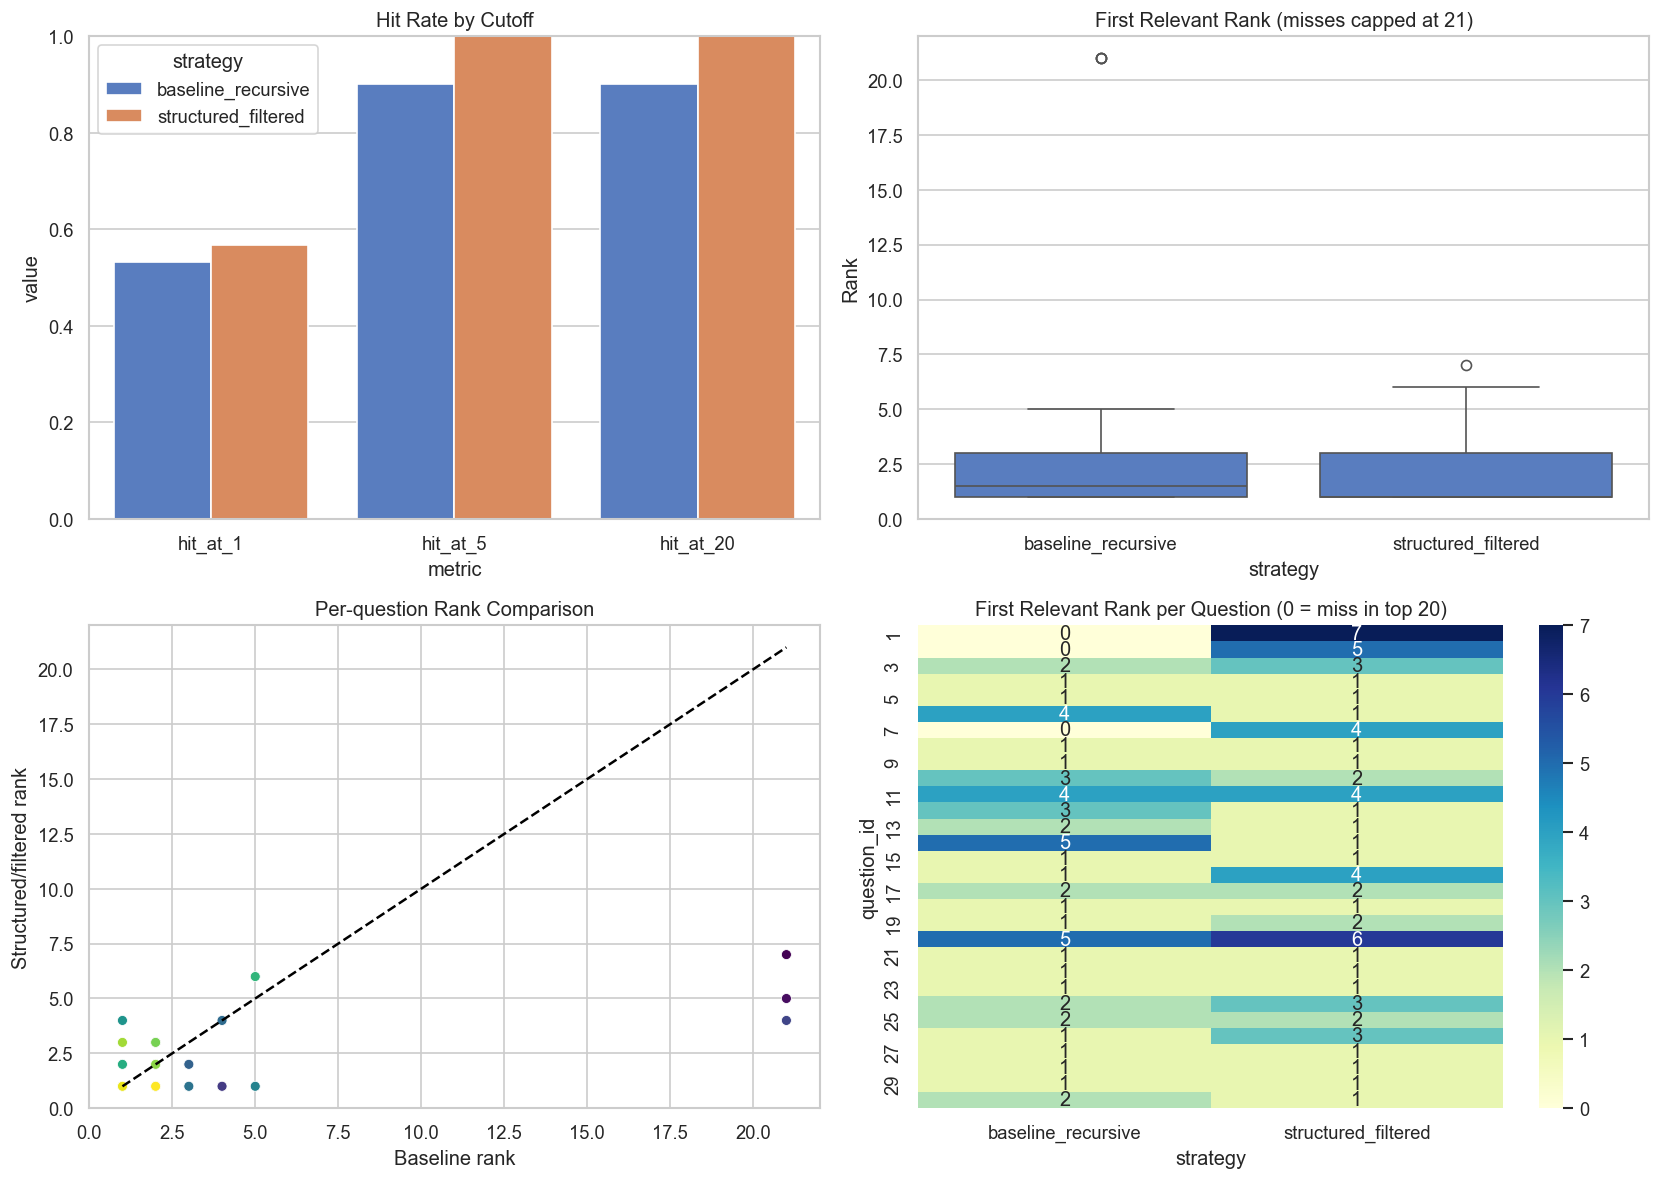

In [11]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

plot_hits = metrics.reset_index()[["strategy", "hit_at_1", "hit_at_5", "hit_at_20"]].melt(id_vars="strategy", var_name="metric", value_name="value")
sns.barplot(data=plot_hits, x="metric", y="value", hue="strategy", ax=axes[0, 0])
axes[0, 0].set_ylim(0, 1)
axes[0, 0].set_title("Hit Rate by Cutoff")

sns.boxplot(data=eval_df, x="strategy", y="rank_for_metrics", ax=axes[0, 1])
axes[0, 1].set_title("First Relevant Rank (misses capped at 21)")
axes[0, 1].set_ylabel("Rank")

rank_pivot = eval_df.pivot(index="question_id", columns="strategy", values="rank_for_metrics").reset_index()
rank_pivot["question_id"] = rank_pivot["question_id"].astype(int)
sns.scatterplot(data=rank_pivot, x="baseline_recursive", y="structured_filtered", hue="question_id", palette="viridis", legend=False, ax=axes[1, 0])
axes[1, 0].plot([1, TOP_K_EVAL + 1], [1, TOP_K_EVAL + 1], linestyle="--", color="black")
axes[1, 0].set_title("Per-question Rank Comparison")
axes[1, 0].set_xlabel("Baseline rank")
axes[1, 0].set_ylabel("Structured/filtered rank")

heatmap_df = eval_df.copy()
heatmap_df["display_rank"] = heatmap_df["first_relevant_rank"].fillna(0)
heatmap_pivot = heatmap_df.pivot(index="question_id", columns="strategy", values="display_rank")
sns.heatmap(heatmap_pivot, annot=True, fmt=".0f", cmap="YlGnBu", ax=axes[1, 1])
axes[1, 1].set_title("First Relevant Rank per Question (0 = miss in top 20)")

plt.tight_layout()
plt.show()


In [12]:
comparison = eval_df.pivot_table(
    index=["question_id", "difficulty", "question"],
    columns="strategy",
    values=["first_relevant_rank", "has_answer_top5", "has_answer_top20"],
    aggfunc="first",
).reset_index()
comparison.columns = [
    col if isinstance(col, str) else "_".join([part for part in col if part])
    for col in comparison.columns
]

comparison["rank_delta"] = comparison["first_relevant_rank_baseline_recursive"].fillna(TOP_K_EVAL + 1) - comparison["first_relevant_rank_structured_filtered"].fillna(TOP_K_EVAL + 1)
comparison.sort_values("rank_delta", ascending=False).head(10)


,question_id,difficulty,question,first_relevant_rank_baseline_recursive,first_relevant_rank_structured_filtered,has_answer_top20_baseline_recursive,has_answer_top20_structured_filtered,has_answer_top5_baseline_recursive,has_answer_top5_structured_filtered,rank_delta
6,7,Easy,What license is used by KDK?,NaN,4.0,False,True,False,True,17.0
1,2,Easy,What is the main goal of the Kalisio Developme...,NaN,5.0,False,True,False,True,16.0
0,1,Easy,What does KDK stand for?,NaN,7.0,False,True,False,True,14.0
13,14,Medium,What is meant by context in KDK data segregation?,5.0,1.0,True,True,True,True,4.0
5,6,Easy,What are the three main API parts of a KDK sub...,4.0,1.0,True,True,True,True,3.0
11,12,Medium,What role do services play in the KDK architec...,3.0,1.0,True,True,True,True,2.0
12,13,Medium,How does KDK represent business data internally?,2.0,1.0,True,True,True,True,1.0
9,10,Easy,What is shown in the KDK global architecture o...,3.0,2.0,True,True,True,True,1.0
29,30,Hard,"Based on the docs, how would you explain KDK t...",2.0,1.0,True,True,True,True,1.0
3,4,Easy,Where can users join the Kalisio community chat?,1.0,1.0,True,True,True,True,0.0


In [13]:
inspect_questions = [1, 7, 15, 24]
rows = []
for qid in inspect_questions:
    for strategy, collection in strategy_map.items():
        question = next(q["question"] for q in questions if q["question_id"] == qid)
        points = retrieve(question, collection, TOP_K_EVAL)
        for rank, point in enumerate(points[:5], start=1):
            payload = point.payload or {}
            rows.append({
                "question_id": qid,
                "strategy": strategy,
                "rank": rank,
                "source": payload.get("source", ""),
                "section_title": payload.get("section_title", ""),
                "score": round(point.score, 4),
                "preview": payload.get("text", "")[:180].replace("\n", " "),
            })

inspection_df = pd.DataFrame(rows)
inspection_df


,question_id,strategy,rank,source,section_title,score,preview
0,1,baseline_recursive,1,about\contributing.md,Contributing,0.7232,# Contributing
1,1,baseline_recursive,2,api\map\components.md,Components,0.7232,# Components
2,1,baseline_recursive,3,api\core\components.md,Components,0.7232,# Components
3,1,baseline_recursive,4,api\map\services.md,Services,0.7232,# Services
4,1,baseline_recursive,5,api\map\composables\composables.project.md,Project,0.6859,## Exposed
5,1,structured_filtered,1,api\core\composables\composables.collection-fi...,Collection Filter / `useCollectionFilter()` / ...,0.6165,## `useCollectionFilter()` ### Overview Re...
6,1,structured_filtered,2,api\core\mixins\mixins.service.md,Service / Props,0.6164,## Props | Prop | Type | Default | Descripti...
7,1,structured_filtered,3,api\core\mixins\mixins.base-editor.md,Base Editor / Computed Properties / `applyButton`,0.6126,### `applyButton` Returns the label for the ...
8,1,structured_filtered,4,api\core\mixins\mixins.base-item.md,Base Item / Methods / `exportItem()`,0.6118,### `exportItem()` Exports the item as a JSO...
9,1,structured_filtered,5,api\map\composables\composables.activity.md,"Activity / `useActivity(name, options)` / Para...",0.6075,"## `useActivity(name, options)` ### Paramete..."


## Reading the Results

- If `structured_filtered` reduces `heading_only` and `short_le_80` substantially, the chunking cleanup is working.
- If `hit_at_5`, `hit_at_20`, or `MRR` improve while using the same embedding model, the gain is coming from chunk quality rather than embedding choice.
- Questions such as `What does KDK stand for?` and `What license is used by KDK?` are especially useful sanity checks because the answers are explicitly present in the docs and should be retrievable.
- If both strategies still miss those questions, the next likely bottlenecks are retrieval method (`dense-only`) and the presence of many short, title-like chunks in the corpus.
